## Import Packages

In [1]:
import numpy as np

from sequentialized_barnard_tests.tools.plotting import (
    compare_success_and_get_cld,
    plot_model_comparison,
)

## Prepare Your Data Here

In [2]:
model_name_list = [
    "Method A",
    "Method B",
    "Method C",
]

success_array_list = [
    np.array([False, True, True, True, True, False, True, True]),  # For Method A. False indicates failure.
    np.array([True, False, False, False, False, False, True, False]),  # For Method B. False indicates failure.
    np.array([False, False, False, False, False, False, False, True]),  # For Method C. False indicates failure.
]

## Specify Your Statistical Analysis Plan

In [3]:
global_confidence_level = 0.95  # Global confidence level across 6 pairwise comparisons.
max_sample_size_per_model = 15  # Maximum possible number of rollouts (per method), according to your evaluation budget.
shuffle = False  # Whether to shuffle the True/False ordering in each success array. Set to False here, assuming each True/False outcome is independent within each success_array.

In [4]:
cld_dict = compare_success_and_get_cld(
    model_name_list,
    success_array_list,
    global_confidence_level,
    max_sample_size_per_model,
    shuffle,
    verbose=True,
)
cld_list = [cld_dict[key] for key in model_name_list]

Statistical Test Specs:
  Method: STEP
  Global Confidence: 0.95
    (0.98333 per comparison)
  Maximum Sample Size per Model: 15

Statistical Test Results (Compact Letter Display):
  CLD for Method A: a
    Success Rate 6 / 8 = 0.75
  CLD for Method B: ab
    Success Rate 2 / 8 = 0.25
  CLD for Method C: b
    Success Rate 1 / 8 = 0.125
Not all models were separated with global confidence of 0.95. Models that share a same letter are not separated from each other with statistical significance. For more information on how to interpret the letters, see: https://en.wikipedia.org/wiki/Compact_letter_display.



Plot generated. Two models that do not share any CLD letters are significantly different.


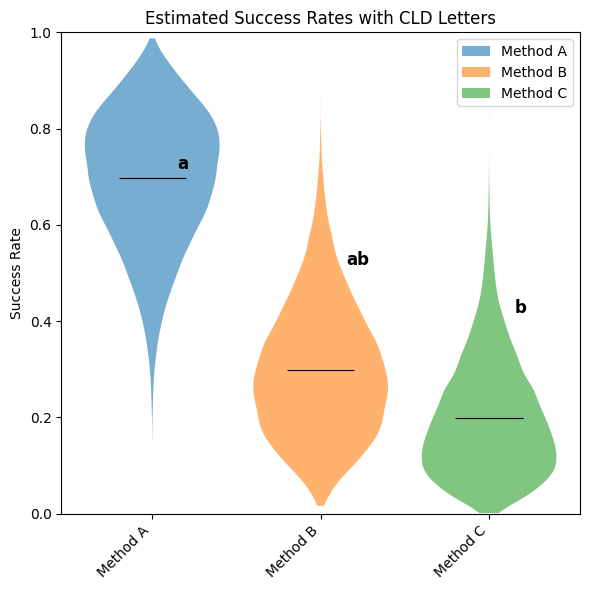

In [6]:
plot_model_comparison(
    model_name_list,
    success_array_list,
    cld_list,
    rng=np.random.default_rng(123), # For plotting violins
)
print("Plot generated. Two models that do not share any CLD letters are significantly different.")